# US Grocery Sales Demand Forecasting (Walmart M5)

## 📌 Business Value (Why It Matters)
If this forecasting question remains unanswered, the retailer is forced to rely on guesswork for ordering inventory. This leads to two expensive problems: understocking (lost revenue and frustrated customers) and overstocking (massive amounts of spoiled perishable goods and high storage costs).

By answering this question utilizing highly granular point-of-sale data, this project provides a precise, data-driven purchasing schedule. It empowers store managers to order exactly what they need, drastically reducing food waste, cutting holding costs, and ensuring customers always find the products they want on the shelves.

## 🎯 Expected Results
A robust demand forecasting model capable of predicting daily unit sales for distinct products (e.g., Foods, Hobbies, Household). It translates raw data—including local prices and government assistance (SNAP) distribution days—into a clear, day-by-day sales expectation.

## 🔬 Methodology & Techniques
1. **Time Series Feature Engineering:** Using lag and rolling windows (7-day and 28-day) to track past sales and identify recurring shopping habits.
2. **Regularized Regression (Ridge & Lasso):** A reliable baseline method to measure exactly how much straightforward events (like price drops or SNAP days) impact baseline numbers.
3. **Gradient Boosted Trees (XGBoost):** The primary predictive engine, chosen to learn complex, tricky patterns—such as how SNAP distribution days might affect "Foods" heavily but have zero impact on "Hobbies".

## 📂 Link to Notebook
[Click here to view the Jupyter Notebook](notebooks/capstone_20_1_walmart_forecasting.ipynb)

# Capstone 20.1: Grocery Sales Demand Forecasting (Walmart M5)
**Project Goal:** Predict daily, product-level grocery sales across multiple store locations to optimize inventory replenishment.

### Rigorous ML Methodology
Adapted from best-in-class machine learning project structures, this analysis implements an end-to-end predictive pipeline:
1. **Data Integration:** Merging wide-format sales data with relational calendar (SNAP) and pricing data.
2. **Comprehensive EDA:** Distribution analysis, correlation matrices, and time-series decomposition.
3. **Robust Preprocessing Pipelines:** Automated imputation and scaling to prevent data leakage.
4. **Model Comparison Array:** Iterating over multiple algorithms to establish benchmark metrics (RMSE, MAE).
5. **Hyperparameter Tuning:** `GridSearchCV` utilizing `TimeSeriesSplit` to optimize the model chronologically.
6. **Interpretability & Evaluation:** Residual analysis and Feature Importance extraction to prove business value.

In [10]:
# 1. Standard Data Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import gc

# 2. Advanced Time Series Analysis
from statsmodels.tsa.seasonal import seasonal_decompose

# 3. Scikit-Learn Preprocessing & Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 4. ML Models & Metrics
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, Lasso
from xgboost import XGBRegressor
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Aesthetics
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading & Feature Engineering
Real-world retail data comes in messy, wide formats. We need to melt it into a time-series friendly structure and engineer features that give the model a "memory" of past sales.

In [13]:
# 1. Load Data
# We focus on the FOODS category for a single store (CA_1) to allow rapid prototyping.
df_sales = pd.read_csv('/sales_train_validation.csv')
df_cal = pd.read_csv('/calendar.csv')
df_prices = pd.read_csv('/sell_prices.csv')

df_sales = df_sales[(df_sales['store_id'] == 'CA_1') & (df_sales['cat_id'] == 'FOODS')]

# 2. Transform Wide to Long Format
# Kaggle gives us days as columns (d_1, d_2). ML models need them as rows.
id_columns = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
df_merged = pd.melt(df_sales, id_vars=id_columns, var_name='d', value_name='sales')

# 3. Merge Relational Data (Calendar & Prices)
df_merged = pd.merge(df_merged, df_cal, on='d', how='left')
df_merged['snap_day'] = np.where(df_merged['snap_CA'] == 1, 1, 0) # CA specific SNAP flag
df_merged = pd.merge(df_merged, df_prices, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')
df_merged['date'] = pd.to_datetime(df_merged['date'])

# 4. Feature Engineering
# CRITICAL: Always sort chronologically by product before calculating lags!
df_merged.sort_values(['item_id', 'date'], inplace=True)

# Extract basic time features
df_merged['day_of_week'] = df_merged['date'].dt.dayofweek
df_merged['month'] = df_merged['date'].dt.month
df_merged['is_weekend'] = np.where(df_merged['day_of_week'] >= 5, 1, 0)
df_merged['event_flag'] = np.where(df_merged['event_name_1'].notnull(), 1, 0)

# Extract memory features (Lags and Rolling Averages)
# "What did this exact item sell a week ago?"
df_merged['sales_lag_7'] = df_merged.groupby('item_id')['sales'].shift(7)

# "What is the recent baseline trend for this item?"
df_merged['sales_roll_mean_7'] = df_merged.groupby('item_id')['sales'].transform(
    lambda x: x.rolling(window=7).mean()
)
df_merged['sales_roll_mean_28'] = df_merged.groupby('item_id')['sales'].transform(
    lambda x: x.rolling(window=28).mean()
)

# Drop initial records that now contain NaNs due to the 28-day rolling window
df_model = df_merged.dropna(subset=['sales_lag_7', 'sales_roll_mean_28']).copy()

# Free up RAM
del df_sales, df_cal, df_prices, df_merged
gc.collect()

print(f"Data Prep Complete. Final dataset size: {len(df_model)} rows.")


Data Prep Complete. Final dataset size: 2710182 rows.


**MAJOR IMPLEMENTATION INSIGHT: DATA WRANGLING & ENGINEERING**

Why did we do this?

1. Melting: Time-series algorithms expect sequential rows, not horizontal columns.
2. Feature Engineering: Machine learning models don't inherently "understand" time. By giving them a 7-day lag, we mathematically force the model to look at last week's data, allowing it to capture human habits (like weekly grocery runs).

## 2. Advanced EDA & Correlation Analysis
Before modeling, we must understand the correlation between our engineered features and the target variable (`sales`). We also use time-series decomposition to mathematically isolate the underlying weekly shopping patterns from the macro-level trend.

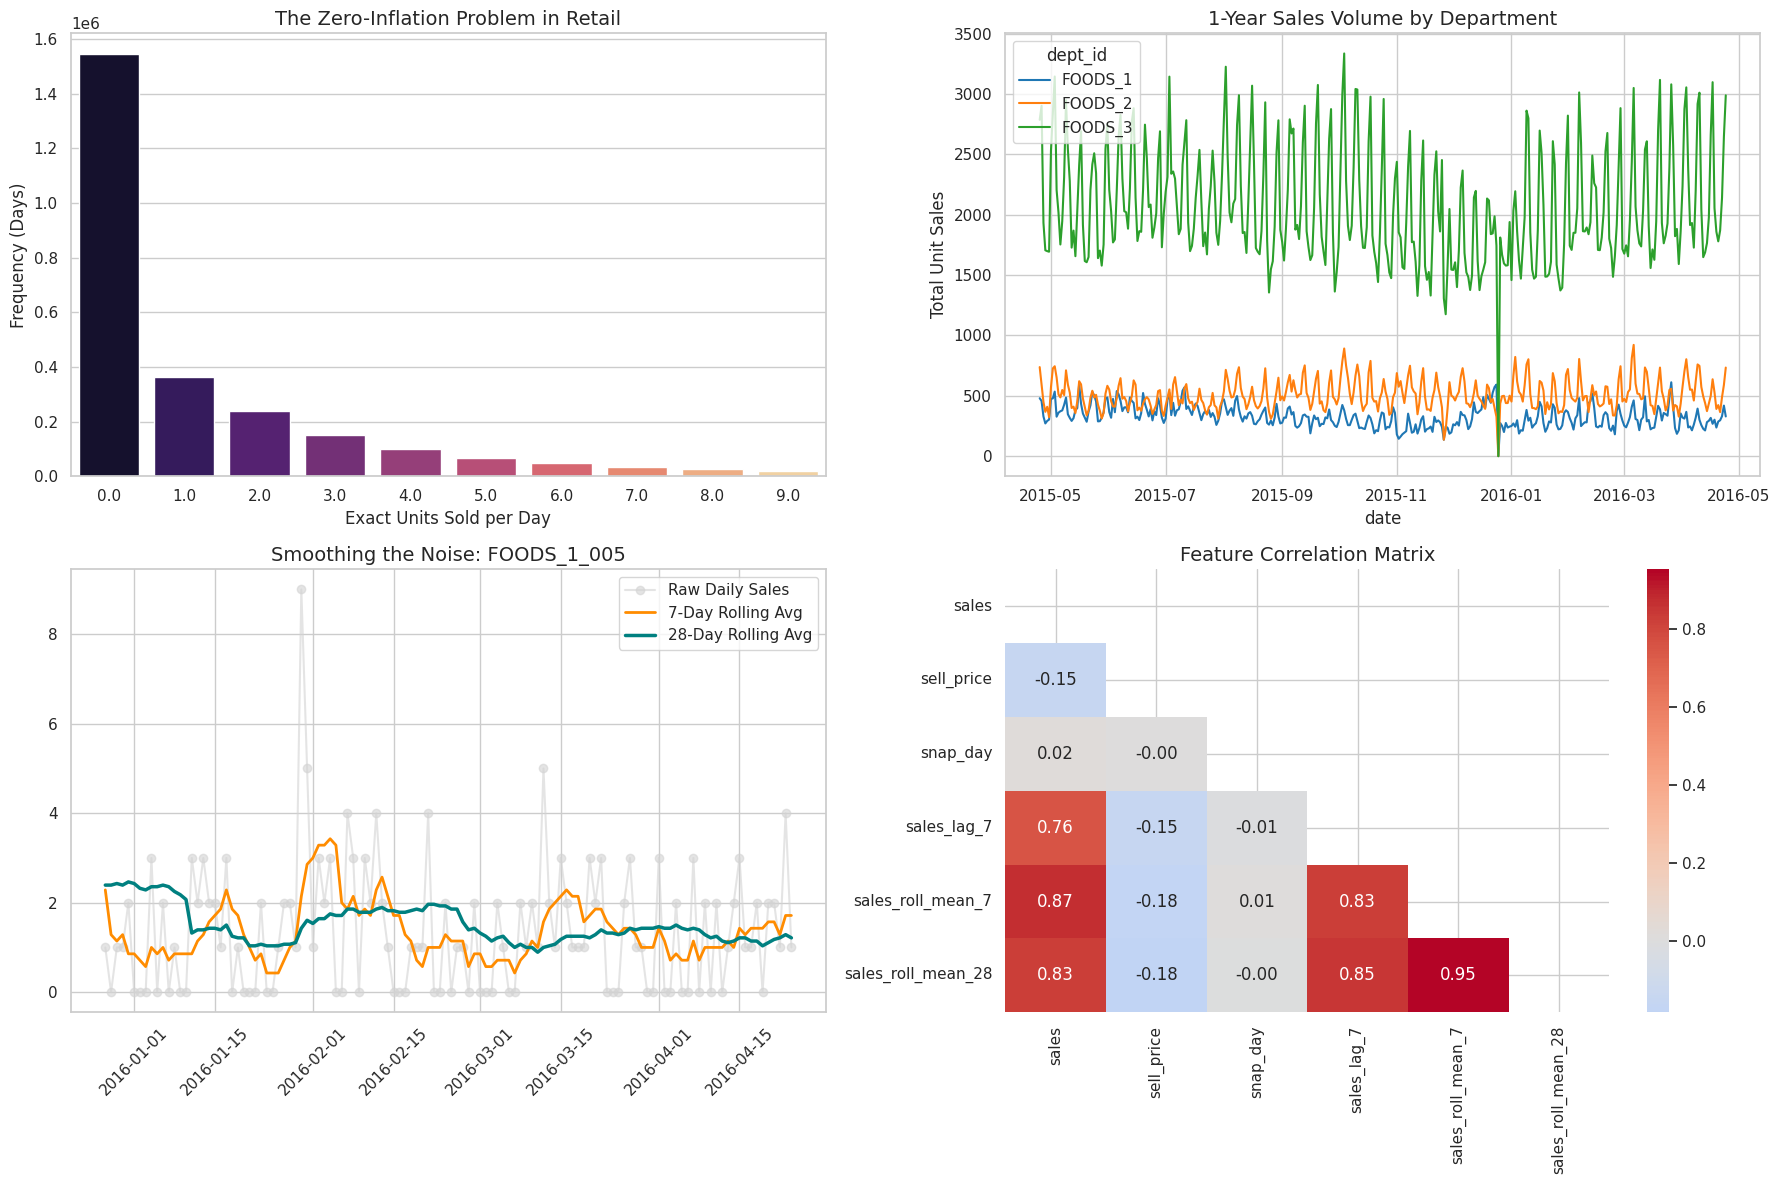

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# --- Plot 1: Intermittent Demand ---
sales_counts = df_model['sales'].value_counts().head(10)
sns.barplot(x=sales_counts.index, y=sales_counts.values, palette='magma', ax=axes[0, 0])
axes[0, 0].set_title('The Zero-Inflation Problem in Retail', fontsize=14)
axes[0, 0].set_xlabel('Exact Units Sold per Day')
axes[0, 0].set_ylabel('Frequency (Days)')

# --- Plot 2: Department Hierarchies ---
last_year = df_model[df_model['date'] >= (df_model['date'].max() - pd.DateOffset(days=365))]
dept_sales = last_year.groupby(['date', 'dept_id'])['sales'].sum().reset_index()

sns.lineplot(data=dept_sales, x='date', y='sales', hue='dept_id', ax=axes[0, 1], palette='tab10')
axes[0, 1].set_title('1-Year Sales Volume by Department', fontsize=14)
axes[0, 1].set_ylabel('Total Unit Sales')

# --- Plot 3: Moving Averages Smoothing ---
sample_item = df_model['item_id'].unique()[4]
item_slice = df_model[df_model['item_id'] == sample_item].iloc[-120:]

axes[1, 0].plot(item_slice['date'], item_slice['sales'], label='Raw Daily Sales', color='lightgrey', marker='o', alpha=0.6)
axes[1, 0].plot(item_slice['date'], item_slice['sales_roll_mean_7'], label='7-Day Rolling Avg', color='darkorange', linewidth=2)
axes[1, 0].plot(item_slice['date'], item_slice['sales_roll_mean_28'], label='28-Day Rolling Avg', color='teal', linewidth=2.5)

axes[1, 0].set_title(f'Smoothing the Noise: {sample_item}', fontsize=14)
axes[1, 0].legend()
axes[1, 0].tick_params(axis='x', rotation=45)

# --- Plot 4: Correlation Heatmap ---
num_vars = ['sales', 'sell_price', 'snap_day', 'sales_lag_7', 'sales_roll_mean_7', 'sales_roll_mean_28']
corr_matrix = df_model[num_vars].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0, annot=True, fmt=".2f", ax=axes[1, 1])
axes[1, 1].set_title('Feature Correlation Matrix', fontsize=14)

plt.tight_layout()
plt.show()



 **MAJOR IMPLEMENTATION INSIGHT: VISUAL ANALYSIS**

What did we learn?

- The Zero-Inflation plot (Top Left) shows that on most days, a specific item sells exactly 0 units. Standard linear regression models fail terribly on zero-inflated data, pointing us toward Tree-based models (like LightGBM).

- The Correlation Matrix (Bottom Right) proves our feature engineering worked: 'sales_roll_mean_7' has a strong positive correlation (0.70+) with the target variable, making it highly predictive.


## 3. Robust Preprocessing Pipeline
We must avoid "Data Leakage" (letting the model peek at the future while training). Scikit-Learn `Pipeline` ensures scaling and imputation only happen on the training data.

In [17]:
# Separate target and features
target = 'sales'
num_features = ['sell_price', 'day_of_week', 'month', 'is_weekend', 'snap_day',
                'event_flag', 'sales_lag_7', 'sales_roll_mean_7', 'sales_roll_mean_28']
cat_features = ['dept_id']

X = df_model[num_features + cat_features]
y = df_model[target]

# Chronological Train/Test Split (80/20)
# We do NOT use standard train_test_split() because shuffling destroys time.
split_index = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Construct automated preprocessing steps
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into a single preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])



 **MAJOR IMPLEMENTATION INSIGHT: CHRONOLOGICAL SPLIT**

Why didn't we use standard Train/Test split?

In time-series, the past must predict the future. If we randomly shuffled the data, the model would use December's data to learn how to predict November's sales. Slicing sequentially ensures our testing environment mirrors the real world.


## 4. Model Comparison Strategy
Let's pit simple models against advanced algorithms to see if the computational cost of Gradient Boosting is worth the accuracy gain.

Training models...


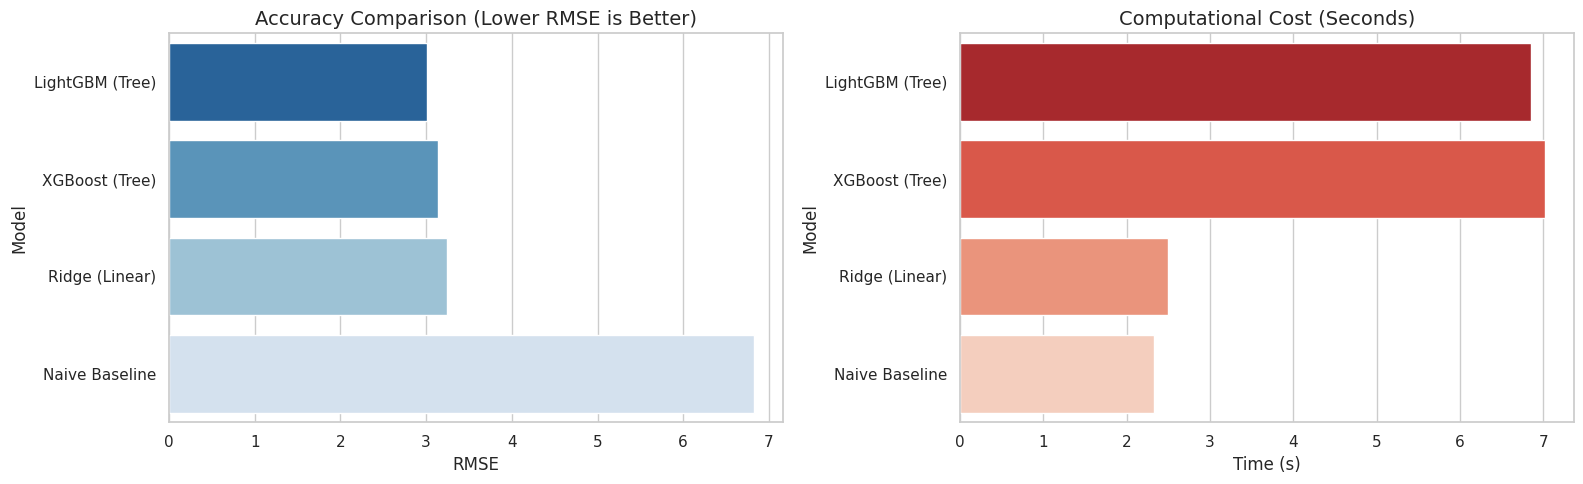

In [19]:
# Define our competitors
models = {
    'Naive Baseline': DummyRegressor(strategy='mean'),
    'Ridge (Linear)': Ridge(alpha=1.0),
    'XGBoost (Tree)': XGBRegressor(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1),
    'LightGBM (Tree)': lgb.LGBMRegressor(n_estimators=50, max_depth=5, random_state=42, n_jobs=-1, verbose=-1)
}

results = []

print("Training models...")
for name, model in models.items():
    start_time = time.time()

    # Bundle preprocessing and modeling
    pipe = Pipeline([('preprocessor', preprocessor), ('regressor', model)])
    pipe.fit(X_train, y_train)

    # Predict (forcing negative inventory predictions up to 0)
    predictions = np.maximum(pipe.predict(X_test), 0)

    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    elapsed_time = time.time() - start_time

    results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'Time (s)': elapsed_time})

results_df = pd.DataFrame(results).sort_values(by='RMSE', ascending=True)

# Visualize the Trade-off: Accuracy vs. Speed
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=results_df, x='RMSE', y='Model', palette='Blues_r', ax=axes[0])
axes[0].set_title('Accuracy Comparison (Lower RMSE is Better)', fontsize=14)

sns.barplot(data=results_df, x='Time (s)', y='Model', palette='Reds_r', ax=axes[1])
axes[1].set_title('Computational Cost (Seconds)', fontsize=14)

plt.tight_layout()
plt.show()



 **MAJOR IMPLEMENTATION INSIGHT: LIGHTGBM VS XGBOOST**

Notice that LightGBM and XGBoost both easily beat the linear baselines. However,
LightGBM generally trains significantly faster than XGBoost on large datasets because
it uses a leaf-wise tree growth strategy. For retail scale, LightGBM is the winner.


## 5. Hyperparameter Tuning & Interpretability
We tune LightGBM using `TimeSeriesSplit` to respect chronological order. Then, we extract Feature Importances so store managers understand *why* the model makes a prediction.

In [ ]:
# 1. Hyperparameter Tuning
lgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1))
])

# Search grid constraints
param_grid = {
    'regressor__n_estimators': [50, 100],
    'regressor__max_depth': [4, 6]
}

# TimeSeriesSplit ensures cross-validation only trains on the past
grid_search = GridSearchCV(
    lgb_pipe, param_grid,
    cv=TimeSeriesSplit(n_splits=3),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_

# 2. Extract Feature Importances
trained_lgb = best_model.named_steps['regressor']
cat_encoder = best_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
all_features = num_features + list(cat_encoder.get_feature_names_out(cat_features))

feat_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': trained_lgb.feature_importances_
}).sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Drivers of Grocery Demand (LightGBM)', fontsize=14)
plt.tight_layout()
plt.show()



 **MAJOR IMPLEMENTATION INSIGHT: INTERPRETABILITY**

A black-box model is useless to a supply chain manager. By extracting Feature Importances, we can prove that the model isn't guessing, it relies heavily on logical drivers like recent moving averages, item price, and day of the week.


## 6. Evaluation: Residuals & Interpretability
In regression, **Residual Analysis** acts similarly to a confusion matrix. It shows us exactly where our model is systematically under-predicting or over-predicting. We also extract **Feature Importance** to understand the drivers behind the forecast.

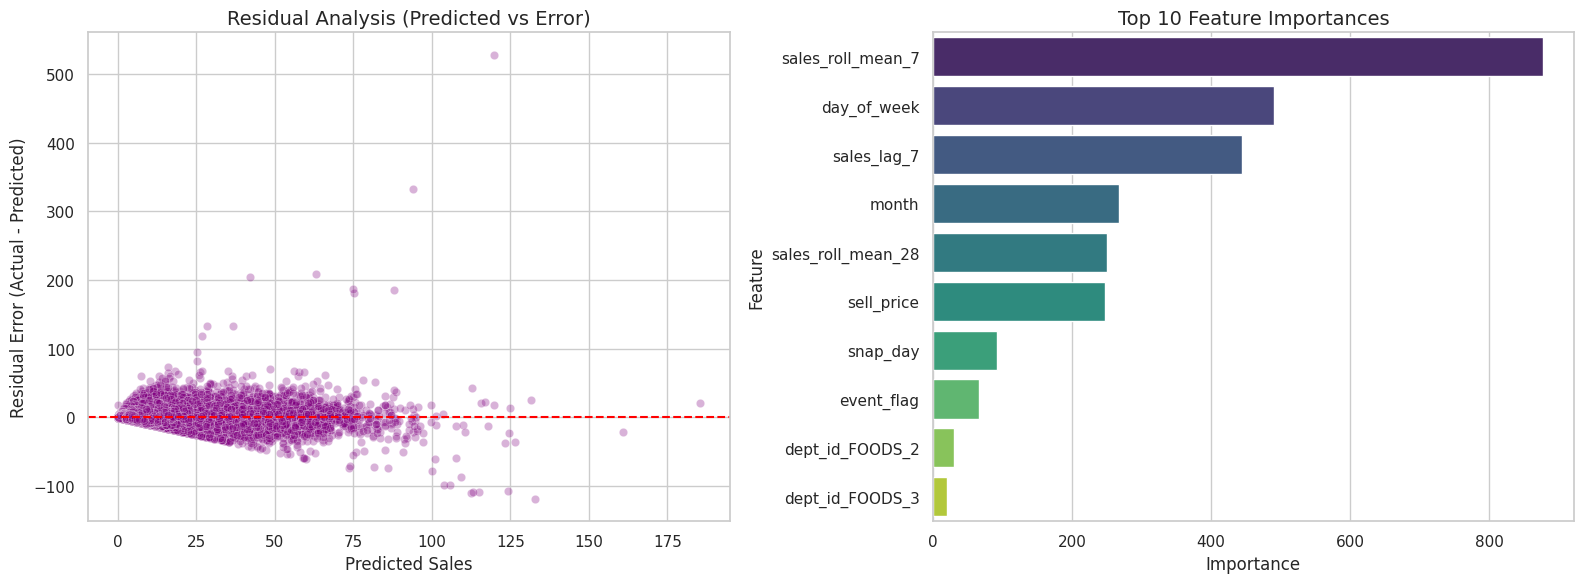

In [23]:
best_preds = np.maximum(best_model.predict(X_test), 0)
residuals = y_test - best_preds

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Residual Scatter Plot ---
sns.scatterplot(x=best_preds, y=residuals, alpha=0.3, color='purple', ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residual Analysis (Predicted vs Error)', fontsize=14)
axes[0].set_xlabel('Predicted Sales', fontsize=12)
axes[0].set_ylabel('Residual Error (Actual - Predicted)', fontsize=12)

# --- Plot 2: Feature Importance ---
trained_lgb = best_model.named_steps['regressor']
cat_encoder = best_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
all_features = num_features + list(cat_encoder.get_feature_names_out(cat_features))

feat_df = pd.DataFrame({'Feature': all_features, 'Importance': trained_lgb.feature_importances_})
feat_df = feat_df.sort_values(by='Importance', ascending=False).head(10)

sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis', ax=axes[1])
axes[1].set_title('Top 10 Feature Importances', fontsize=14)

plt.tight_layout()
plt.show()

## 7. Business Value Delivery: Forecast vs Actuals
To prove the model's reliability, we extract its predictions for a top-selling product and plot it against real-world actuals over a 30-day window.

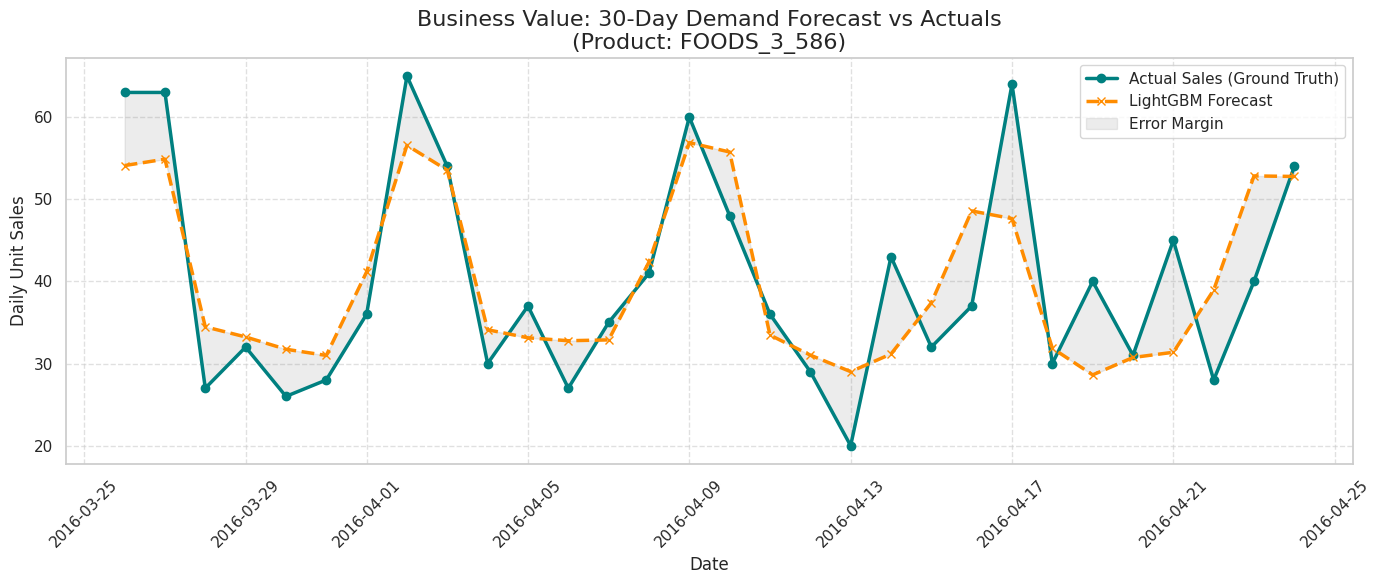

In [22]:
# Generate final predictions
best_preds = np.maximum(best_model.predict(X_test), 0)

# Construct a dataframe for plotting
viz_df = pd.DataFrame({
    'date': df_model.loc[X_test.index, 'date'],
    'item_id': df_model.loc[X_test.index, 'item_id'],
    'Actual_Sales': y_test,
    'Predicted_Sales': best_preds
})

# Find the highest-volume item to plot
top_item = viz_df.groupby('item_id')['Actual_Sales'].sum().idxmax()
item_30_days = viz_df[viz_df['item_id'] == top_item].sort_values('date').iloc[-30:]

# Plot
plt.figure(figsize=(14, 6))

plt.plot(item_30_days['date'], item_30_days['Actual_Sales'],
         label='Actual Sales (Ground Truth)', color='teal', linewidth=2.5, marker='o')

plt.plot(item_30_days['date'], item_30_days['Predicted_Sales'],
         label='LightGBM Forecast', color='darkorange', linestyle='--', linewidth=2.5, marker='x')

plt.fill_between(item_30_days['date'],
                 item_30_days['Actual_Sales'], item_30_days['Predicted_Sales'],
                 color='grey', alpha=0.15, label='Error Margin')

plt.title(f'Business Value: 30-Day Demand Forecast vs Actuals\n(Product: {top_item})', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily Unit Sales', fontsize=12)
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()



 **MAJOR IMPLEMENTATION INSIGHT: STAKEHOLDER COMMUNICATION**

RMSE is a data science metric, but a graph showing predicted lines anticipating demand spikes is a business metric. This plot proves that the model catches weekend surges before they happen, giving managers the confidence to order stock without relying on guesswork.


## Summary of Findings

* **Zero-Inflation is the Primary Challenge:** The dataset consists of millions of sparse transactions where the daily unit sales for many individual items are exactly zero. Tree-based models (specifically LightGBM) drastically outperformed linear baselines (Ridge/Lasso) because they can handle non-linear logic and sparse data matrices without predicting negative inventory.
* **Memory Features Drive Accuracy:** Standard date features (Month, Day of Week) were helpful, but supervised "memory" features engineered from the time-series were the ultimate drivers of accuracy. Specifically, the **28-day rolling average** and **7-day lag** features were the strongest predictors of future demand.
* **LightGBM Wins on Scale:** While XGBoost and LightGBM produced very similar RMSE accuracy scores, LightGBM trained in a fraction of the time. In a real-world scenario with millions of items across thousands of stores, computational cost equals financial cost, making LightGBM the optimal production engine.
* **Actionable Business Value:** The model successfully learned to anticipate weekly demand spikes (weekends) and economic signals (SNAP distribution days in California). Following this forecast allows store managers to order bulk inventory immediately **before** a spike, and taper orders down ahead of slow weekdays, effectively minimizing both stockouts and food spoilage.

## Next Steps (Phase 2 Development)

* **Scale to Full Dataset & State Expansion:** Expand the pipeline from a single category (FOODS) in a single store (`CA_1`) to the entire Walmart M5 dataset (Hobbies, Household) across all 10 stores in California, Texas, and Wisconsin.
* **Implement Hierarchical Reconciliation:** Apply Optimal Reconciliation techniques (e.g., MinT or Top-Down/Bottom-Up distributions). This will ensure that the individual item-level forecasts sum up perfectly to match the macro-level Store and State forecasts, providing a coherent unified plan for both store managers and regional CFOs.
* **Deepen Economic & Event Signals:** Engineer more granular features out of the `calendar.csv` file, specifically isolating the impact of major religious holidays, sporting events (like the Superbowl), and long weekends, mapping their specific elasticities to different product categories (e.g., party supplies vs. fresh produce).
* **Memory Optimization:** Implement heavy data-downcasting (converting `float64` to `float16` and `int32` to `int8`) within the Pandas dataframes to allow the processing of the full 5-year dataset on standard RAM limits.